<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/Kenyan_Health_Statistics_Clustering_Project_by_OMOKE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import zipfile

# Unzipping the dataset
zip_path = '/content/Health_Indicators_In_Kenya.csv.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Loading the dataset
# Note: Assuming the CSV filename inside the zip matches the zip prefix
df = pd.read_csv('/content/Health_Indicators_In_Kenya.csv')

# Display the first 5 rows
display(df.head())

/tmp/ipykernel_1583/2527361981.py:11: DtypeWarning: Columns (12,13,14,15,29,30,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Health_Indicators_In_Kenya.csv')


,GHO (CODE),GHO (DISPLAY),GHO (URL),PUBLISHSTATE (CODE),PUBLISHSTATE (DISPLAY),PUBLISHSTATE (URL),YEAR (CODE),YEAR (DISPLAY),YEAR (URL),REGION (CODE),...,CHILDCAUSE (CODE),CHILDCAUSE (DISPLAY),CHILDCAUSE (URL),Display Value,Numeric,Low,High,StdErr,StdDev,Comments
0,#indicator+code,#indicator+name,#indicator+url,#status+code,#status+name,NaN,NaN,#date+year,NaN,#region+code,...,NaN,NaN,NaN,NaN,#indicator+value+num,NaN,NaN,NaN,NaN,NaN
1,GBD_DALYRTAGE,"Age-standardized DALYs (per 100,000)",https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,NaN,2000,2000,NaN,AFR,...,NaN,NaN,NaN,"90,442",90441.71875,NaN,NaN,NaN,NaN,NaN
2,GBD_DALYRTAGE,"Age-standardized DALYs (per 100,000)",https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,NaN,2012,2012,NaN,AFR,...,NaN,NaN,NaN,"5,386",5385.52002,NaN,NaN,NaN,NaN,NaN
3,WHS2_126,Distribution of years of life lost by major ca...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,NaN,2000,2000,NaN,AFR,...,NaN,NaN,NaN,82,82.00000,NaN,NaN,NaN,NaN,NaN
4,WHOSIS_000004,Adult mortality rate (probability of dying bet...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,NaN,2001,2001,NaN,AFR,...,NaN,NaN,NaN,465,464.95230,NaN,NaN,NaN,NaN,NaN


In [2]:
# Statistical description of the dataset
display(df.describe())

,PUBLISHSTATE (URL),YEAR (URL),REGION (URL),WORLDBANKINCOMEGROUP (URL),COUNTRY (URL),AGEGROUP (URL),SEX (URL),GHECAUSES (URL),CHILDCAUSE (URL),Low,High,StdErr,StdDev
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.623100e+04,1.623000e+04,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.918969e+03,1.509379e+04,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.341411e+05,2.222187e+05,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.115990e+00,7.755097e+00,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.810000e+01,2.910000e+01,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.742919e+01,8.453423e+01,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.270000e+06,9.619000e+06,NaN,NaN


In [3]:
# Information about the dataset (columns, types, null values)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29154 entries, 0 to 29153
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   GHO (CODE)                      29154 non-null  object 
 1   GHO (DISPLAY)                   29154 non-null  object 
 2   GHO (URL)                       26680 non-null  object 
 3   PUBLISHSTATE (CODE)             29154 non-null  object 
 4   PUBLISHSTATE (DISPLAY)          29154 non-null  object 
 5   PUBLISHSTATE (URL)              0 non-null      float64
 6   YEAR (CODE)                     29112 non-null  object 
 7   YEAR (DISPLAY)                  29113 non-null  object 
 8   YEAR (URL)                      0 non-null      float64
 9   REGION (CODE)                   29144 non-null  object 
 10  REGION (DISPLAY)                29144 non-null  object 
 11  REGION (URL)                    0 non-null      float64
 12  WORLDBANKINCOMEGROUP (CODE)     

In [4]:
# Drop columns where all values are missing
initial_cols = df.columns.tolist()
df_cleaned = df.dropna(axis=1, how='all')

dropped_cols = [c for c in initial_cols if c not in df_cleaned.columns]
print(f"Dropped {len(dropped_cols)} columns that were entirely empty:")
print(dropped_cols)

# Update df reference
df = df_cleaned
display(df.head())

Dropped 11 columns that were entirely empty:
['PUBLISHSTATE (URL)', 'YEAR (URL)', 'REGION (URL)', 'WORLDBANKINCOMEGROUP (URL)', 'COUNTRY (URL)', 'AGEGROUP (URL)', 'SEX (URL)', 'GHECAUSES (URL)', 'CHILDCAUSE (URL)', 'StdErr', 'StdDev']


,GHO (CODE),GHO (DISPLAY),GHO (URL),PUBLISHSTATE (CODE),PUBLISHSTATE (DISPLAY),YEAR (CODE),YEAR (DISPLAY),REGION (CODE),REGION (DISPLAY),WORLDBANKINCOMEGROUP (CODE),...,SEX (DISPLAY),GHECAUSES (CODE),GHECAUSES (DISPLAY),CHILDCAUSE (CODE),CHILDCAUSE (DISPLAY),Display Value,Numeric,Low,High,Comments
0,#indicator+code,#indicator+name,#indicator+url,#status+code,#status+name,NaN,#date+year,#region+code,#region+name,NaN,...,#sex+name,NaN,NaN,NaN,NaN,NaN,#indicator+value+num,NaN,NaN,NaN
1,GBD_DALYRTAGE,"Age-standardized DALYs (per 100,000)",https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2000,2000,AFR,Africa,NaN,...,NaN,GHE000,All Causes,NaN,NaN,"90,442",90441.71875,NaN,NaN,NaN
2,GBD_DALYRTAGE,"Age-standardized DALYs (per 100,000)",https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2012,2012,AFR,Africa,NaN,...,NaN,GHE151,Injuries,NaN,NaN,"5,386",5385.52002,NaN,NaN,NaN
3,WHS2_126,Distribution of years of life lost by major ca...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2000,2000,AFR,Africa,NaN,...,NaN,GHE001,Communicable & other Group I,NaN,NaN,82,82.00000,NaN,NaN,NaN
4,WHOSIS_000004,Adult mortality rate (probability of dying bet...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2001,2001,AFR,Africa,NaN,...,Both sexes,NaN,NaN,NaN,NaN,465,464.95230,NaN,NaN,NaN


In [5]:
# 1. Remove the first row containing metadata placeholders
df = df.iloc[1:].reset_index(drop=True)

# 2. Identify columns with more than 90% null values
threshold = 0.9
null_pct = df.isnull().mean()
mostly_null_cols = null_pct[null_pct > threshold].index.tolist()

print(f"Dropping {len(mostly_null_cols)} columns with > 90% missing values:")
print(mostly_null_cols)

df.drop(columns=mostly_null_cols, inplace=True)

# Display current state
print(f"Remaining columns: {df.shape[1]}")
df.info()
display(df.head())

Dropping 7 columns with > 90% missing values:
['WORLDBANKINCOMEGROUP (CODE)', 'WORLDBANKINCOMEGROUP (DISPLAY)', 'GHECAUSES (CODE)', 'GHECAUSES (DISPLAY)', 'CHILDCAUSE (CODE)', 'CHILDCAUSE (DISPLAY)', 'Comments']
Remaining columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29153 entries, 0 to 29152
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   GHO (CODE)              29153 non-null  object 
 1   GHO (DISPLAY)           29153 non-null  object 
 2   GHO (URL)               26679 non-null  object 
 3   PUBLISHSTATE (CODE)     29153 non-null  object 
 4   PUBLISHSTATE (DISPLAY)  29153 non-null  object 
 5   YEAR (CODE)             29112 non-null  object 
 6   YEAR (DISPLAY)          29112 non-null  object 
 7   REGION (CODE)           29143 non-null  object 
 8   REGION (DISPLAY)        29143 non-null  object 
 9   STARTYEAR               29112 non-null  object 
 10  ENDYEAR         

,GHO (CODE),GHO (DISPLAY),GHO (URL),PUBLISHSTATE (CODE),PUBLISHSTATE (DISPLAY),YEAR (CODE),YEAR (DISPLAY),REGION (CODE),REGION (DISPLAY),STARTYEAR,...,COUNTRY (CODE),COUNTRY (DISPLAY),AGEGROUP (CODE),AGEGROUP (DISPLAY),SEX (CODE),SEX (DISPLAY),Display Value,Numeric,Low,High
0,GBD_DALYRTAGE,"Age-standardized DALYs (per 100,000)",https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2000,2000,AFR,Africa,2000,...,KEN,Kenya,NaN,NaN,NaN,NaN,"90,442",90441.71875,NaN,NaN
1,GBD_DALYRTAGE,"Age-standardized DALYs (per 100,000)",https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2012,2012,AFR,Africa,2012,...,KEN,Kenya,NaN,NaN,NaN,NaN,"5,386",5385.52002,NaN,NaN
2,WHS2_126,Distribution of years of life lost by major ca...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2000,2000,AFR,Africa,2000,...,KEN,Kenya,NaN,NaN,NaN,NaN,82,82.00000,NaN,NaN
3,WHOSIS_000004,Adult mortality rate (probability of dying bet...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2001,2001,AFR,Africa,2001,...,KEN,Kenya,NaN,NaN,BTSX,Both sexes,465,464.95230,NaN,NaN
4,WHOSIS_000004,Adult mortality rate (probability of dying bet...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2002,2002,AFR,Africa,2002,...,KEN,Kenya,NaN,NaN,FMLE,Female,461,461.20110,NaN,NaN


In [6]:
from sklearn.impute import SimpleImputer
import numpy as np

# Separate columns by type
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

# Impute numeric columns with mean
num_imputer = SimpleImputer(strategy='mean')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

# Impute categorical columns with most frequent value
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

# Verify that there are no more null values
print("Missing values after imputation:")
print(df.isnull().sum().sum())
display(df.head())

Missing values after imputation:
0


,GHO (CODE),GHO (DISPLAY),GHO (URL),PUBLISHSTATE (CODE),PUBLISHSTATE (DISPLAY),YEAR (CODE),YEAR (DISPLAY),REGION (CODE),REGION (DISPLAY),STARTYEAR,...,COUNTRY (CODE),COUNTRY (DISPLAY),AGEGROUP (CODE),AGEGROUP (DISPLAY),SEX (CODE),SEX (DISPLAY),Display Value,Numeric,Low,High
0,GBD_DALYRTAGE,"Age-standardized DALYs (per 100,000)",https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2000,2000,AFR,Africa,2000,...,KEN,Kenya,YEARS18-PLUS,18+ years,FMLE,Female,"90,442",90441.71875,8918.969174,15093.791284
1,GBD_DALYRTAGE,"Age-standardized DALYs (per 100,000)",https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2012,2012,AFR,Africa,2012,...,KEN,Kenya,YEARS18-PLUS,18+ years,FMLE,Female,"5,386",5385.52002,8918.969174,15093.791284
2,WHS2_126,Distribution of years of life lost by major ca...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2000,2000,AFR,Africa,2000,...,KEN,Kenya,YEARS18-PLUS,18+ years,FMLE,Female,82,82.00000,8918.969174,15093.791284
3,WHOSIS_000004,Adult mortality rate (probability of dying bet...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2001,2001,AFR,Africa,2001,...,KEN,Kenya,YEARS18-PLUS,18+ years,BTSX,Both sexes,465,464.95230,8918.969174,15093.791284
4,WHOSIS_000004,Adult mortality rate (probability of dying bet...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2002,2002,AFR,Africa,2002,...,KEN,Kenya,YEARS18-PLUS,18+ years,FMLE,Female,461,461.20110,8918.969174,15093.791284


In [7]:
# Convert 'Numeric' to float, handling any non-numeric strings that might remain
df['Numeric'] = pd.to_numeric(df['Numeric'], errors='coerce')

# Group by 'GHO (DISPLAY)' and calculate the mean
avg_values = df.groupby('GHO (DISPLAY)')['Numeric'].mean().reset_index()

# Sort for better visibility
avg_values = avg_values.sort_values(by='Numeric', ascending=False)

display(avg_values.head(10))

,GHO (DISPLAY),Numeric
1420,Tobacco tax revenues - total excise (specific ...,1.269264e+10
1090,Population,4.051268e+07
1277,Reported number of people requiring interventi...,1.508943e+07
991,Number of suspected malaria cases,1.387374e+07
1278,Reported number of tests performed where resul...,1.054764e+07
1442,Total number of malaria cases (presumed + con...,8.556049e+06
984,Number of presumed malaria cases,6.582530e+06
958,Number of malaria cases treated with any first...,5.862406e+06
959,Number of malaria cases treated with artemisin...,5.673166e+06
962,Number of malaria suspects examined by microscopy,5.504861e+06


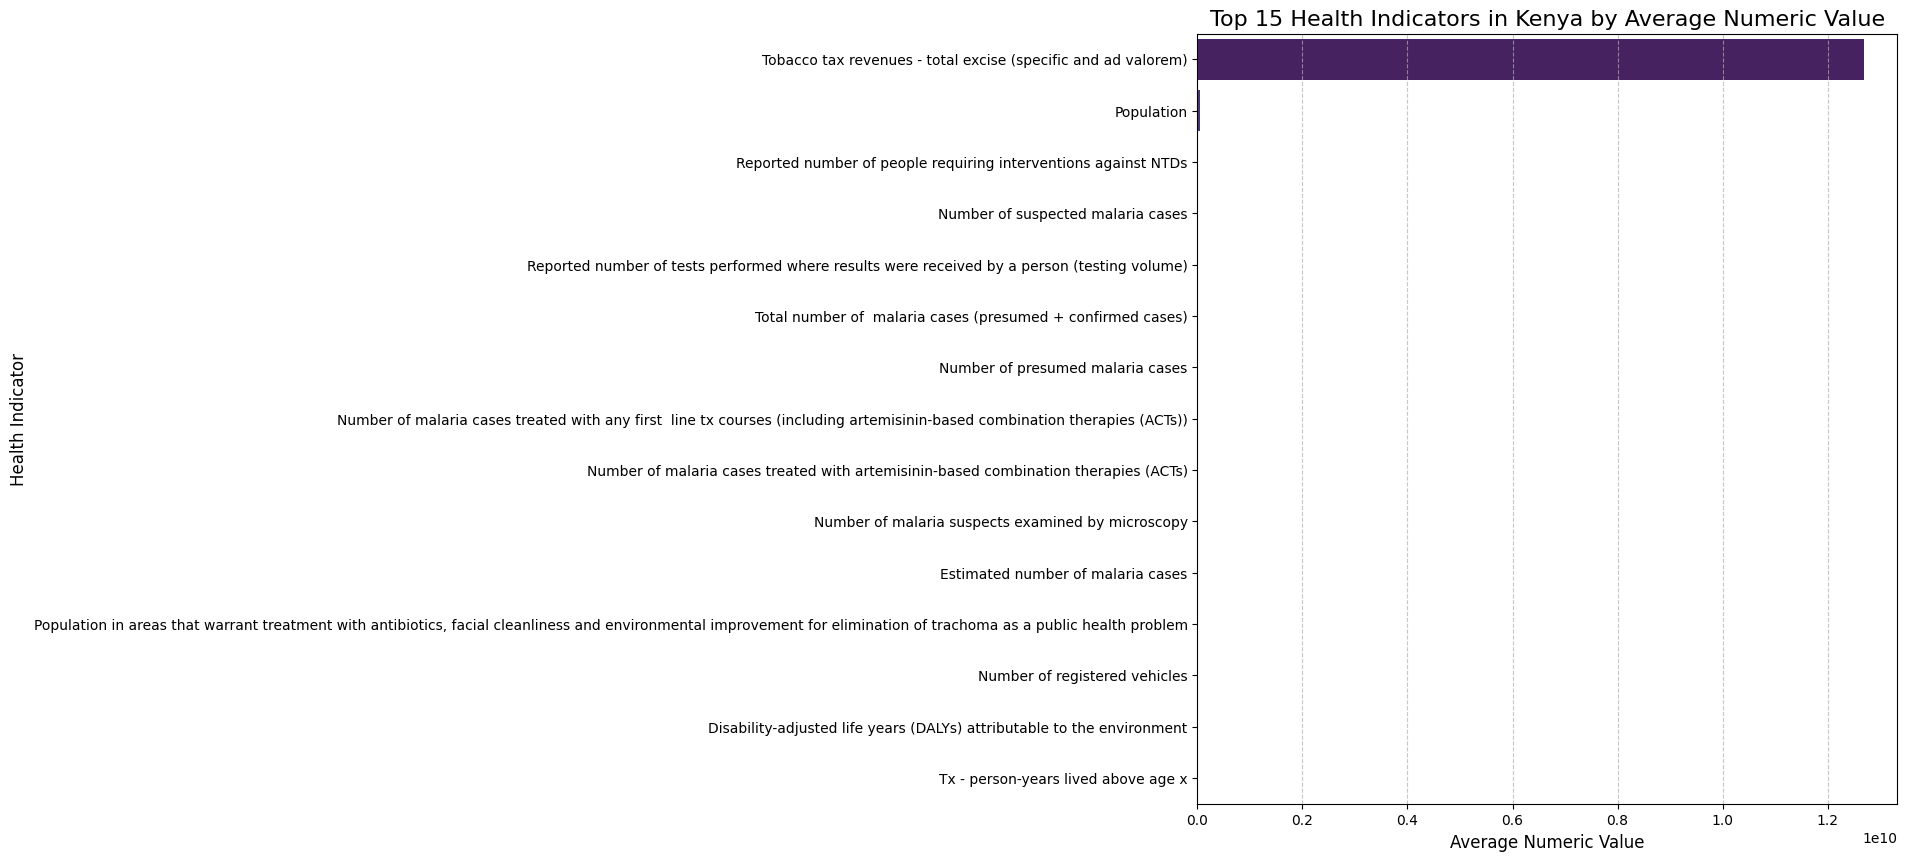

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting the top 15 indicators for a clear visualization
top_15_indicators = avg_values.head(15)

plt.figure(figsize=(14, 10))
# Updated to assign hue to avoid FutureWarning and set legend=False
sns.barplot(x='Numeric', y='GHO (DISPLAY)', data=top_15_indicators, hue='GHO (DISPLAY)', palette='viridis', legend=False)

plt.title('Top 15 Health Indicators in Kenya by Average Numeric Value', fontsize=16)
plt.xlabel('Average Numeric Value', fontsize=12)
plt.ylabel('Health Indicator', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjusted margins to ensure long labels fit
plt.subplots_adjust(left=0.4)
plt.show()

In [11]:
# Recalculate to show the distribution and handle the high concentration in top indicators
total_numeric_sum = avg_values['Numeric'].sum()
avg_values['Percentage'] = (avg_values['Numeric'] / total_numeric_sum) * 100
avg_values['Cumulative_Percentage'] = avg_values['Percentage'].cumsum()

# Since the first row is > 95%, we'll show the top indicators to illustrate the concentration
print(f"Total Indicators: {len(avg_values)}")
print("Top indicators and their cumulative contribution:")

# Displaying the top 10 to show where the 95% threshold is crossed
display(avg_values.head(10)[['GHO (DISPLAY)', 'Numeric', 'Percentage', 'Cumulative_Percentage']])

Total Indicators: 1553
Top indicators and their cumulative contribution:


,GHO (DISPLAY),Numeric,Percentage,Cumulative_Percentage
1420,Tobacco tax revenues - total excise (specific ...,1.269264e+10,98.802100,98.802100
1090,Population,4.051268e+07,0.315359,99.117459
1277,Reported number of people requiring interventi...,1.508943e+07,0.117459,99.234918
991,Number of suspected malaria cases,1.387374e+07,0.107996,99.342914
1278,Reported number of tests performed where resul...,1.054764e+07,0.082105,99.425019
1442,Total number of malaria cases (presumed + con...,8.556049e+06,0.066602,99.491621
984,Number of presumed malaria cases,6.582530e+06,0.051240,99.542861
958,Number of malaria cases treated with any first...,5.862406e+06,0.045634,99.588495
959,Number of malaria cases treated with artemisin...,5.673166e+06,0.044161,99.632656
962,Number of malaria suspects examined by microscopy,5.504861e+06,0.042851,99.675507


In [12]:
# Set pandas to display all columns
pd.set_option('display.max_columns', None)

# Display the first few rows of the cleaned dataframe
display(df.head())

,GHO (CODE),GHO (DISPLAY),GHO (URL),PUBLISHSTATE (CODE),PUBLISHSTATE (DISPLAY),YEAR (CODE),YEAR (DISPLAY),REGION (CODE),REGION (DISPLAY),STARTYEAR,ENDYEAR,COUNTRY (CODE),COUNTRY (DISPLAY),AGEGROUP (CODE),AGEGROUP (DISPLAY),SEX (CODE),SEX (DISPLAY),Display Value,Numeric,Low,High
0,GBD_DALYRTAGE,"Age-standardized DALYs (per 100,000)",https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2000,2000,AFR,Africa,2000,2000,KEN,Kenya,YEARS18-PLUS,18+ years,FMLE,Female,"90,442",90441.71875,8918.969174,15093.791284
1,GBD_DALYRTAGE,"Age-standardized DALYs (per 100,000)",https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2012,2012,AFR,Africa,2012,2012,KEN,Kenya,YEARS18-PLUS,18+ years,FMLE,Female,"5,386",5385.52002,8918.969174,15093.791284
2,WHS2_126,Distribution of years of life lost by major ca...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2000,2000,AFR,Africa,2000,2000,KEN,Kenya,YEARS18-PLUS,18+ years,FMLE,Female,82,82.00000,8918.969174,15093.791284
3,WHOSIS_000004,Adult mortality rate (probability of dying bet...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2001,2001,AFR,Africa,2001,2001,KEN,Kenya,YEARS18-PLUS,18+ years,BTSX,Both sexes,465,464.95230,8918.969174,15093.791284
4,WHOSIS_000004,Adult mortality rate (probability of dying bet...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2002,2002,AFR,Africa,2002,2002,KEN,Kenya,YEARS18-PLUS,18+ years,FMLE,Female,461,461.20110,8918.969174,15093.791284


In [13]:
cols_to_drop = ['GHO (CODE)', 'REGION (CODE)', 'SEX (CODE)']
df.drop(columns=cols_to_drop, inplace=True)

# Display the updated dataframe columns
print(f"Columns remaining: {df.shape[1]}")
display(df.head())

Columns remaining: 18


,GHO (DISPLAY),GHO (URL),PUBLISHSTATE (CODE),PUBLISHSTATE (DISPLAY),YEAR (CODE),YEAR (DISPLAY),REGION (DISPLAY),STARTYEAR,ENDYEAR,COUNTRY (CODE),COUNTRY (DISPLAY),AGEGROUP (CODE),AGEGROUP (DISPLAY),SEX (DISPLAY),Display Value,Numeric,Low,High
0,"Age-standardized DALYs (per 100,000)",https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2000,2000,Africa,2000,2000,KEN,Kenya,YEARS18-PLUS,18+ years,Female,"90,442",90441.71875,8918.969174,15093.791284
1,"Age-standardized DALYs (per 100,000)",https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2012,2012,Africa,2012,2012,KEN,Kenya,YEARS18-PLUS,18+ years,Female,"5,386",5385.52002,8918.969174,15093.791284
2,Distribution of years of life lost by major ca...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2000,2000,Africa,2000,2000,KEN,Kenya,YEARS18-PLUS,18+ years,Female,82,82.00000,8918.969174,15093.791284
3,Adult mortality rate (probability of dying bet...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2001,2001,Africa,2001,2001,KEN,Kenya,YEARS18-PLUS,18+ years,Both sexes,465,464.95230,8918.969174,15093.791284
4,Adult mortality rate (probability of dying bet...,https://www.who.int/data/gho/indicator-metadat...,PUBLISHED,Published,2002,2002,Africa,2002,2002,KEN,Kenya,YEARS18-PLUS,18+ years,Female,461,461.20110,8918.969174,15093.791284


In [16]:
# Set display options to show full column content
pd.set_option('display.max_colwidth', None)

# Display unique indicator names and their corresponding URLs
unique_gho = df[['GHO (DISPLAY)', 'GHO (URL)']].drop_duplicates().head(20)
display(unique_gho)

,GHO (DISPLAY),GHO (URL)
0,Age-standardized DALYs per 100000,https:www.who.intdataghoindicator-metadata-registryimr-details157
2,Distribution of years of life lost by major cause group,https:www.who.intdataghoindicator-metadata-registryimr-details90
3,Adult mortality rate probability of dying between 15 and 60 years per 1000 population,https:www.who.intdataghoindicator-metadata-registryimr-details64
17,Distribution of causes of death among children aged < 5 years %,https:www.who.intdataghoindicator-metadata-registryimr-details89
207,Life expectancy at age 60 years,https:www.who.intdataghoindicator-metadata-registryimr-details2977
211,nMx - age-specific death rate between ages x and xn,https:www.who.intdataghoindicator-metadata-registryimr-details29
282,ndx - number of people dying between ages x and xn,https:www.who.intdataghoindicator-metadata-registryimr-details32
353,nqx - probability of dying between ages x and xn,https:www.who.intdataghoindicator-metadata-registryimr-details30
1622,lx - number of people left alive at age x,https:www.who.intdataghoindicator-metadata-registryimr-details31
1714,nLx - person-years lived between ages x and xn,https:www.who.intdataghoindicator-metadata-registryimr-details33


In [17]:
# Display the current state of the cleaned dataset
display(df.head())

# Also print the shape to confirm dimensions
print(f"Current dataset shape: {df.shape}")

,GHO (DISPLAY),GHO (URL),PUBLISHSTATE (CODE),PUBLISHSTATE (DISPLAY),YEAR (CODE),YEAR (DISPLAY),REGION (DISPLAY),STARTYEAR,ENDYEAR,COUNTRY (CODE),COUNTRY (DISPLAY),AGEGROUP (CODE),AGEGROUP (DISPLAY),SEX (DISPLAY),Display Value,Numeric,Low,High
0,Age-standardized DALYs per 100000,https:www.who.intdataghoindicator-metadata-registryimr-details157,PUBLISHED,Published,2000,2000,Africa,2000,2000,KEN,Kenya,YEARS18-PLUS,18 years,Female,90442,90441.71875,8918.969174,15093.791284
1,Age-standardized DALYs per 100000,https:www.who.intdataghoindicator-metadata-registryimr-details157,PUBLISHED,Published,2012,2012,Africa,2012,2012,KEN,Kenya,YEARS18-PLUS,18 years,Female,5386,5385.52002,8918.969174,15093.791284
2,Distribution of years of life lost by major cause group,https:www.who.intdataghoindicator-metadata-registryimr-details90,PUBLISHED,Published,2000,2000,Africa,2000,2000,KEN,Kenya,YEARS18-PLUS,18 years,Female,82,82.00000,8918.969174,15093.791284
3,Adult mortality rate probability of dying between 15 and 60 years per 1000 population,https:www.who.intdataghoindicator-metadata-registryimr-details64,PUBLISHED,Published,2001,2001,Africa,2001,2001,KEN,Kenya,YEARS18-PLUS,18 years,Both sexes,465,464.95230,8918.969174,15093.791284
4,Adult mortality rate probability of dying between 15 and 60 years per 1000 population,https:www.who.intdataghoindicator-metadata-registryimr-details64,PUBLISHED,Published,2002,2002,Africa,2002,2002,KEN,Kenya,YEARS18-PLUS,18 years,Female,461,461.20110,8918.969174,15093.791284


Current dataset shape: (29153, 18)


In [18]:
# Drop the specified code columns
cols_to_drop_extra = ['PUBLISHSTATE (CODE)', 'COUNTRY (CODE)']
df.drop(columns=cols_to_drop_extra, inplace=True, errors='ignore')

# Display the updated dataframe
print(f"Columns remaining: {df.shape[1]}")
display(df.head())

Columns remaining: 16


,GHO (DISPLAY),GHO (URL),PUBLISHSTATE (DISPLAY),YEAR (CODE),YEAR (DISPLAY),REGION (DISPLAY),STARTYEAR,ENDYEAR,COUNTRY (DISPLAY),AGEGROUP (CODE),AGEGROUP (DISPLAY),SEX (DISPLAY),Display Value,Numeric,Low,High
0,Age-standardized DALYs per 100000,https:www.who.intdataghoindicator-metadata-registryimr-details157,Published,2000,2000,Africa,2000,2000,Kenya,YEARS18-PLUS,18 years,Female,90442,90441.71875,8918.969174,15093.791284
1,Age-standardized DALYs per 100000,https:www.who.intdataghoindicator-metadata-registryimr-details157,Published,2012,2012,Africa,2012,2012,Kenya,YEARS18-PLUS,18 years,Female,5386,5385.52002,8918.969174,15093.791284
2,Distribution of years of life lost by major cause group,https:www.who.intdataghoindicator-metadata-registryimr-details90,Published,2000,2000,Africa,2000,2000,Kenya,YEARS18-PLUS,18 years,Female,82,82.00000,8918.969174,15093.791284
3,Adult mortality rate probability of dying between 15 and 60 years per 1000 population,https:www.who.intdataghoindicator-metadata-registryimr-details64,Published,2001,2001,Africa,2001,2001,Kenya,YEARS18-PLUS,18 years,Both sexes,465,464.95230,8918.969174,15093.791284
4,Adult mortality rate probability of dying between 15 and 60 years per 1000 population,https:www.who.intdataghoindicator-metadata-registryimr-details64,Published,2002,2002,Africa,2002,2002,Kenya,YEARS18-PLUS,18 years,Female,461,461.20110,8918.969174,15093.791284


In [19]:
unique_countries = df['COUNTRY (DISPLAY)'].unique()
print(f'Unique values in COUNTRY (DISPLAY): {unique_countries}')

Unique values in COUNTRY (DISPLAY): ['Kenya']


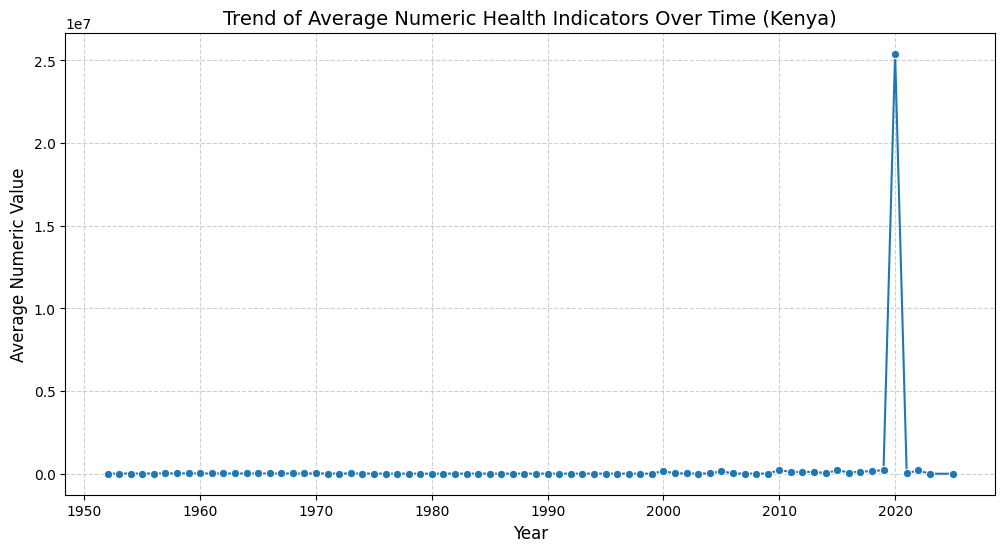

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure STARTYEAR is treated as numeric for plotting
df['STARTYEAR_NUM'] = pd.to_numeric(df['STARTYEAR'], errors='coerce')

# Calculate the yearly mean of Numeric values
yearly_trend = df.groupby('STARTYEAR_NUM')['Numeric'].mean().reset_index()

# Plotting the trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_trend, x='STARTYEAR_NUM', y='Numeric', marker='o')

plt.title('Trend of Average Numeric Health Indicators Over Time (Kenya)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Numeric Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

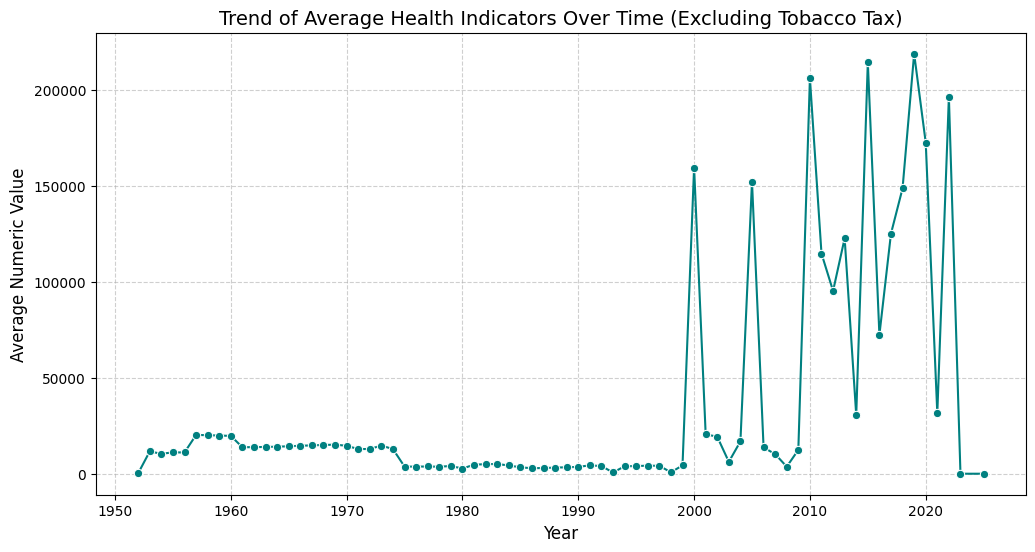

In [21]:
# Filter out indicators related to Tobacco tax revenues
df_filtered = df[~df['GHO (DISPLAY)'].str.contains('Tobacco tax revenues', case=False, na=False)]

# Calculate the yearly mean of Numeric values for the filtered data
yearly_trend_filtered = df_filtered.groupby('STARTYEAR_NUM')['Numeric'].mean().reset_index()

# Plotting the adjusted trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_trend_filtered, x='STARTYEAR_NUM', y='Numeric', marker='o', color='teal')

plt.title('Trend of Average Health Indicators Over Time (Excluding Tobacco Tax)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Numeric Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [22]:
# 1. Calculate average numeric value for each unique GHO indicator
gho_averages = df_filtered.groupby('GHO (DISPLAY)')['Numeric'].mean().sort_values(ascending=False).reset_index()
print('Top 10 Average Numeric Values by Indicator (Filtered):')
display(gho_averages.head(10))

Top 10 Average Numeric Values by Indicator (Filtered):


,GHO (DISPLAY),Numeric
0,Population,4.051268e+07
1,Reported number of people requiring interventions against NTDs,1.508943e+07
2,Number of suspected malaria cases,1.387374e+07
3,Reported number of tests performed where results were received by a person testing volume,1.054764e+07
4,Total number of malaria cases presumed confirmed cases,8.556049e+06
5,Number of presumed malaria cases,6.582530e+06
6,Number of malaria cases treated with any first line tx courses including artemisinin-based combination therapies ACTs,5.862406e+06
7,Number of malaria cases treated with artemisinin-based combination therapies ACTs,5.673166e+06
8,Number of malaria suspects examined by microscopy,5.504861e+06
9,Estimated number of malaria cases,4.111202e+06


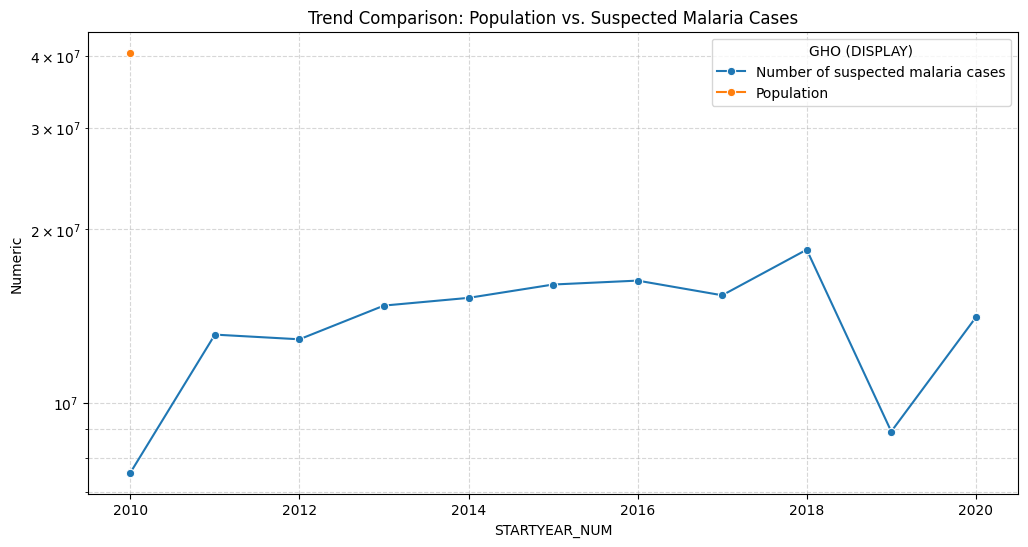

In [23]:
# 2. Compare trends of population and number of suspected malaria cases
indicators_to_compare = ['Population', 'Number of suspected malaria cases']
trend_comparison = df_filtered[df_filtered['GHO (DISPLAY)'].isin(indicators_to_compare)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_comparison, x='STARTYEAR_NUM', y='Numeric', hue='GHO (DISPLAY)', marker='o')
plt.title('Trend Comparison: Population vs. Suspected Malaria Cases')
plt.yscale('log')  # Using log scale due to potential magnitude differences
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

In [24]:
# 3. Identify top 10 indicators driving the trend after 1995
df_post_1995 = df_filtered[df_filtered['STARTYEAR_NUM'] > 1995]
top_post_1995 = df_post_1995.groupby('GHO (DISPLAY)')['Numeric'].mean().sort_values(ascending=False).head(10).reset_index()

print('Top 10 Indicators Driving the Trend Since 1995:')
display(top_post_1995)

Top 10 Indicators Driving the Trend Since 1995:


,GHO (DISPLAY),Numeric
0,Population,4.051268e+07
1,Reported number of people requiring interventions against NTDs,1.508943e+07
2,Number of suspected malaria cases,1.387374e+07
3,Reported number of tests performed where results were received by a person testing volume,1.054764e+07
4,Total number of malaria cases presumed confirmed cases,8.556049e+06
5,Number of presumed malaria cases,6.582530e+06
6,Number of malaria cases treated with any first line tx courses including artemisinin-based combination therapies ACTs,5.862406e+06
7,Number of malaria cases treated with artemisinin-based combination therapies ACTs,5.673166e+06
8,Number of malaria suspects examined by microscopy,5.504861e+06
9,Estimated number of malaria cases,4.111202e+06


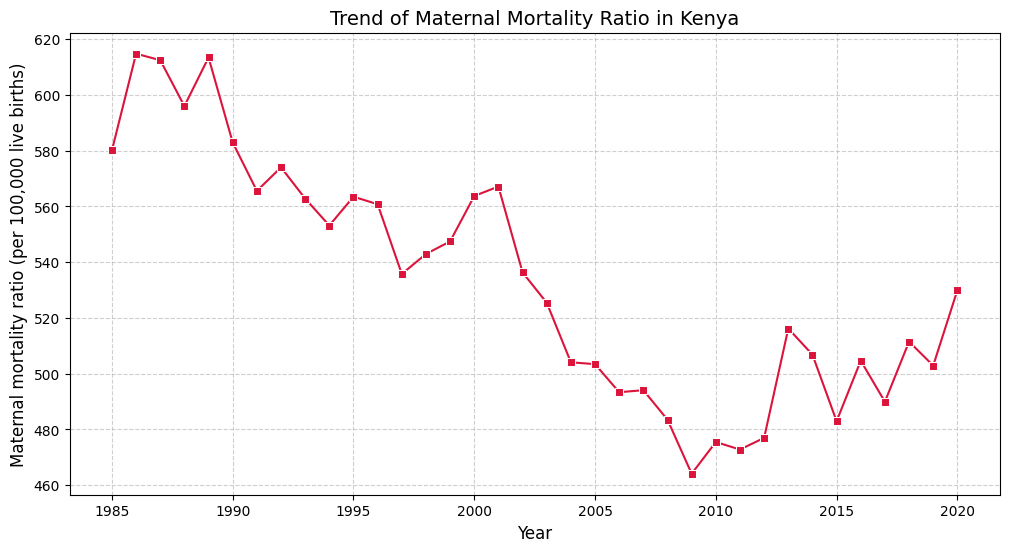

In [25]:
# Filter for Maternal mortality ratio
maternal_mortality = df_filtered[df_filtered['GHO (DISPLAY)'].str.contains('Maternal mortality ratio', case=False, na=False)]

# Calculate yearly mean
maternal_trend = maternal_mortality.groupby('STARTYEAR_NUM')['Numeric'].mean().reset_index()

# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(data=maternal_trend, x='STARTYEAR_NUM', y='Numeric', marker='s', color='crimson')

plt.title('Trend of Maternal Mortality Ratio in Kenya', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Maternal mortality ratio (per 100,000 live births)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

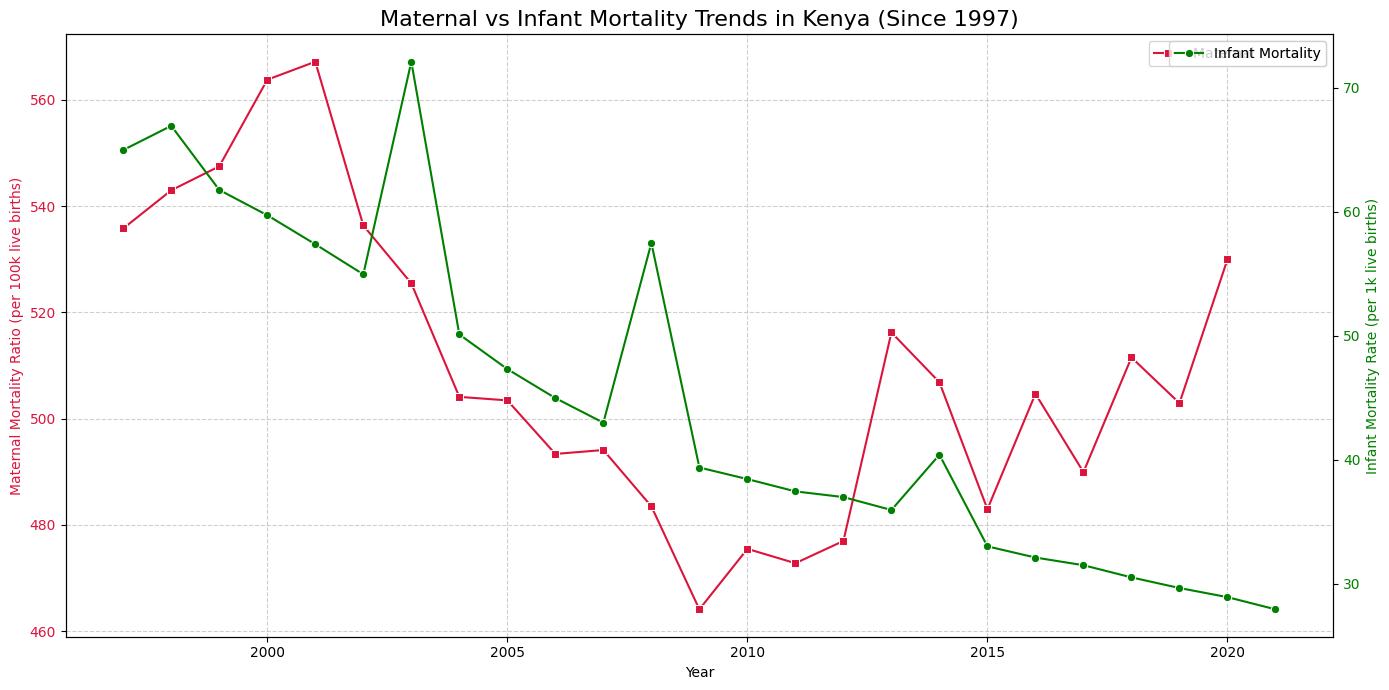

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for Infant mortality rate and limit to 1997 onwards
infant_mortality = df_filtered[
    (df_filtered['GHO (DISPLAY)'].str.contains('Infant mortality rate', case=False, na=False)) &
    (df_filtered['STARTYEAR_NUM'] >= 1997)
]

# Filter Maternal mortality for the same period
maternal_mortality_97 = maternal_mortality[maternal_mortality['STARTYEAR_NUM'] >= 1997]

# Calculate yearly mean for infant mortality
infant_trend_97 = infant_mortality.groupby('STARTYEAR_NUM')['Numeric'].mean().reset_index()
maternal_trend_97 = maternal_mortality_97.groupby('STARTYEAR_NUM')['Numeric'].mean().reset_index()

# Create the plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Maternal Mortality on the first y-axis
color1 = 'crimson'
ax1.set_xlabel('Year')
ax1.set_ylabel('Maternal Mortality Ratio (per 100k live births)', color=color1)
sns.lineplot(data=maternal_trend_97, x='STARTYEAR_NUM', y='Numeric', marker='s', color=color1, ax=ax1, label='Maternal Mortality')
ax1.tick_params(axis='y', labelcolor=color1)

# Create a second y-axis for Infant Mortality
ax2 = ax1.twinx()
color2 = 'green'
ax2.set_ylabel('Infant Mortality Rate (per 1k live births)', color=color2)
sns.lineplot(data=infant_trend_97, x='STARTYEAR_NUM', y='Numeric', marker='o', color=color2, ax=ax2, label='Infant Mortality')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Maternal vs Infant Mortality Trends in Kenya (Since 1997)', fontsize=16)
ax1.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()

In [30]:
merged_mortality = pd.merge(maternal_trend_97, infant_trend_97, on='STARTYEAR_NUM', suffixes=('_maternal', '_infant'))

correlation = merged_mortality['Numeric_maternal'].corr(merged_mortality['Numeric_infant'])

print(f"Pearson Correlation between Maternal and Infant Mortality (1997-2020): {correlation:.4f}")

display(merged_mortality.head())

Pearson Correlation between Maternal and Infant Mortality (1997-2020): 0.5851


,STARTYEAR_NUM,Numeric_maternal,Numeric_infant
0,1997,535.78141,64.977307
1,1998,542.95893,66.926746
2,1999,547.46361,61.756033
3,2000,563.76120,59.719417
4,2001,567.14421,57.379120


In [31]:
import numpy as np

# Filter data from 1997 onwards
df_97 = df_filtered[df_filtered['STARTYEAR_NUM'] >= 1997]

# Group by indicator and year to get yearly averages
trends_df = df_97.groupby(['GHO (DISPLAY)', 'STARTYEAR_NUM'])['Numeric'].mean().reset_index()

# Identify indicators with at least 10 years of data to ensure reliable trends
indicator_counts = trends_df['GHO (DISPLAY)'].value_counts()
long_term_indicators = indicator_counts[indicator_counts >= 10].index

# Calculate the total change (slope) for these indicators using simple linear regression
indicator_slopes = []
for indicator in long_term_indicators:
    subset = trends_df[trends_df['GHO (DISPLAY)'] == indicator].dropna()
    if len(subset) < 10: continue

    # Normalize numeric values to compare slopes across different scales (z-score like)
    # or just calculate percentage change
    start_val = subset.iloc[0]['Numeric']
    end_val = subset.iloc[-1]['Numeric']

    if start_val > 0:
        total_pct_change = ((end_val - start_val) / start_val) * 100
        indicator_slopes.append({'Indicator': indicator, 'Total % Change': total_pct_change, 'Start Value': start_val, 'End Value': end_val})

# Create a dataframe of the trends
trends_summary = pd.DataFrame(indicator_slopes).sort_values(by='Total % Change', ascending=False)

print("Top 5 Increasing Trends (Significant Indicators since 1997):")
display(trends_summary.head(5))

print("\nTop 5 Decreasing Trends (Significant Indicators since 1997):")
display(trends_summary.tail(5))

Top 5 Increasing Trends (Significant Indicators since 1997):


,Indicator,Total % Change,Start Value,End Value
17,Population with primary reliance on clean fuels and technologies for cooking in millions,4302.683059,0.184367,8.117080
19,Proportion of population with primary reliance on clean fuels and technologies for cooking %,1755.555556,1.500000,27.833333
185,Disbursements to recipient countries Million constant 2009 US$,1657.869507,37.550000,660.080000
162,Cases started on MDR-TB treatment,1635.714286,28.000000,486.000000
158,Retreatment cases: other,1342.345277,307.000000,4428.000000



Top 5 Decreasing Trends (Significant Indicators since 1997):


,Indicator,Total % Change,Start Value,End Value
0,Number of new reported cases of human African trypanosomiasis T.b. rhodesiense,-100.0,5.00,0.0
48,Poliomyelitis - number of reported cases,-100.0,14.00,0.0
87,Neonatal tetanus - number of reported cases,-100.0,27.00,0.0
137,Total tetanus - number of reported cases,-100.0,27.00,0.0
196,Production in 1000s hectolitres,-100.0,3.79,0.0


### Visualizing Significant Non-Mortality Trends
Based on the analysis above, let's visualize two specific indicators that show strong, meaningful shifts in Kenya's health landscape.

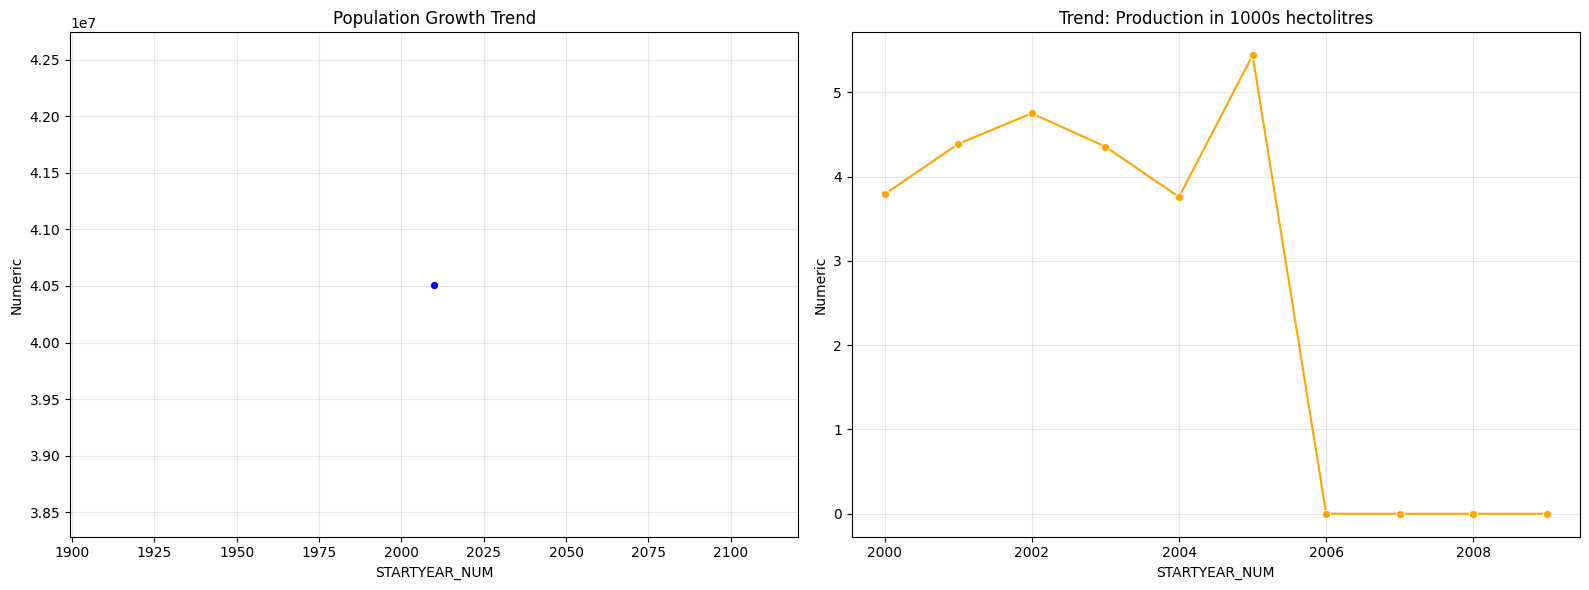

In [32]:
# Example: Visualizing two contrasting strong trends
# We'll pick Population (steady increase) and another significant declining indicator identified above
top_decline = trends_summary.iloc[-1]['Indicator']

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Population Trend
sns.lineplot(data=trends_df[trends_df['GHO (DISPLAY)'] == 'Population'], x='STARTYEAR_NUM', y='Numeric', ax=ax[0], marker='o', color='blue')
ax[0].set_title('Population Growth Trend')
ax[0].grid(True, alpha=0.3)

# Plot 2: Sharpest Declining Indicator
sns.lineplot(data=trends_df[trends_df['GHO (DISPLAY)'] == top_decline], x='STARTYEAR_NUM', y='Numeric', ax=ax[1], marker='o', color='orange')
ax[1].set_title(f'Trend: {top_decline}')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
import pandas as pd

# 1. Prepare Clean Fuel Trend Data
clean_fuel_indicator = 'Proportion of population with primary reliance on clean fuels and technologies for cooking %'
clean_fuel_df = trends_df[trends_df['GHO (DISPLAY)'] == clean_fuel_indicator].rename(columns={'Numeric': 'Clean_Fuel_Pct'})

# 2. Merge with our existing mortality trend data (merged_mortality already contains maternal and infant since 1997)
# merged_mortality has columns: STARTYEAR_NUM, Numeric_maternal, Numeric_infant
correlation_df = pd.merge(merged_mortality, clean_fuel_df[['STARTYEAR_NUM', 'Clean_Fuel_Pct']], on='STARTYEAR_NUM')

# 3. Calculate Correlations
corr_matrix = correlation_df[['Clean_Fuel_Pct', 'Numeric_maternal', 'Numeric_infant']].corr()

print("Correlation Matrix (Clean Fuel vs. Mortality since 1997):")
display(corr_matrix)

# Extract specific values
corr_maternal = corr_matrix.loc['Clean_Fuel_Pct', 'Numeric_maternal']
corr_infant = corr_matrix.loc['Clean_Fuel_Pct', 'Numeric_infant']

print(f"\nCorrelation between Clean Fuel Adoption and Maternal Mortality: {corr_maternal:.4f}")
print(f"Correlation between Clean Fuel Adoption and Infant Mortality: {corr_infant:.4f}")

Correlation Matrix (Clean Fuel vs. Mortality since 1997):


,Clean_Fuel_Pct,Numeric_maternal,Numeric_infant
Clean_Fuel_Pct,1.000000,-0.371362,-0.868113
Numeric_maternal,-0.371362,1.000000,0.585132
Numeric_infant,-0.868113,0.585132,1.000000



Correlation between Clean Fuel Adoption and Maternal Mortality: -0.3714
Correlation between Clean Fuel Adoption and Infant Mortality: -0.8681


### Visualizing the Relationship
Let's look at how these metrics have moved together over time using a dual-axis plot to normalize the scales.

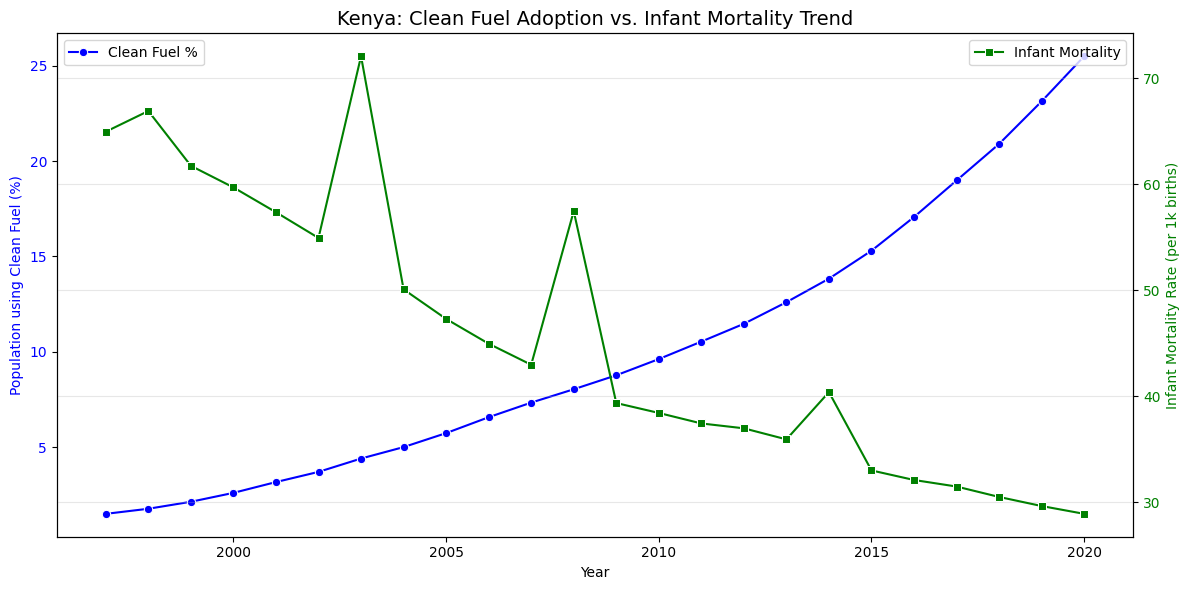

In [34]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Clean Fuel % on primary axis
color_fuel = 'blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Population using Clean Fuel (%)', color=color_fuel)
sns.lineplot(data=correlation_df, x='STARTYEAR_NUM', y='Clean_Fuel_Pct', marker='o', color=color_fuel, ax=ax1, label='Clean Fuel %')
ax1.tick_params(axis='y', labelcolor=color_fuel)

# Plot Infant Mortality on secondary axis
ax2 = ax1.twinx()
color_infant = 'green'
ax2.set_ylabel('Infant Mortality Rate (per 1k births)', color=color_infant)
sns.lineplot(data=correlation_df, x='STARTYEAR_NUM', y='Numeric_infant', marker='s', color=color_infant, ax=ax2, label='Infant Mortality')
ax2.tick_params(axis='y', labelcolor=color_infant)

plt.title('Kenya: Clean Fuel Adoption vs. Infant Mortality Trend', fontsize=14)
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [35]:
from sklearn.model_selection import train_test_split

# Splitting the dataframe 'df' into 70% training and 30% testing sets
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")

Training set shape: (20407, 17)
Testing set shape: (8746, 17)


In [36]:
missing_values_train = train_df.isnull().sum()
print("Missing values in train_df:")
display(missing_values_train[missing_values_train > 0] if missing_values_train.sum() > 0 else "No missing values found.")

Missing values in train_df:


'No missing values found.'

### **Hierarchical Clustering of Annual Health Trends**
To identify distinct periods or "health profiles" in Kenya's history, we will use Agglomerative Clustering on the indicators that have consistent data across years.

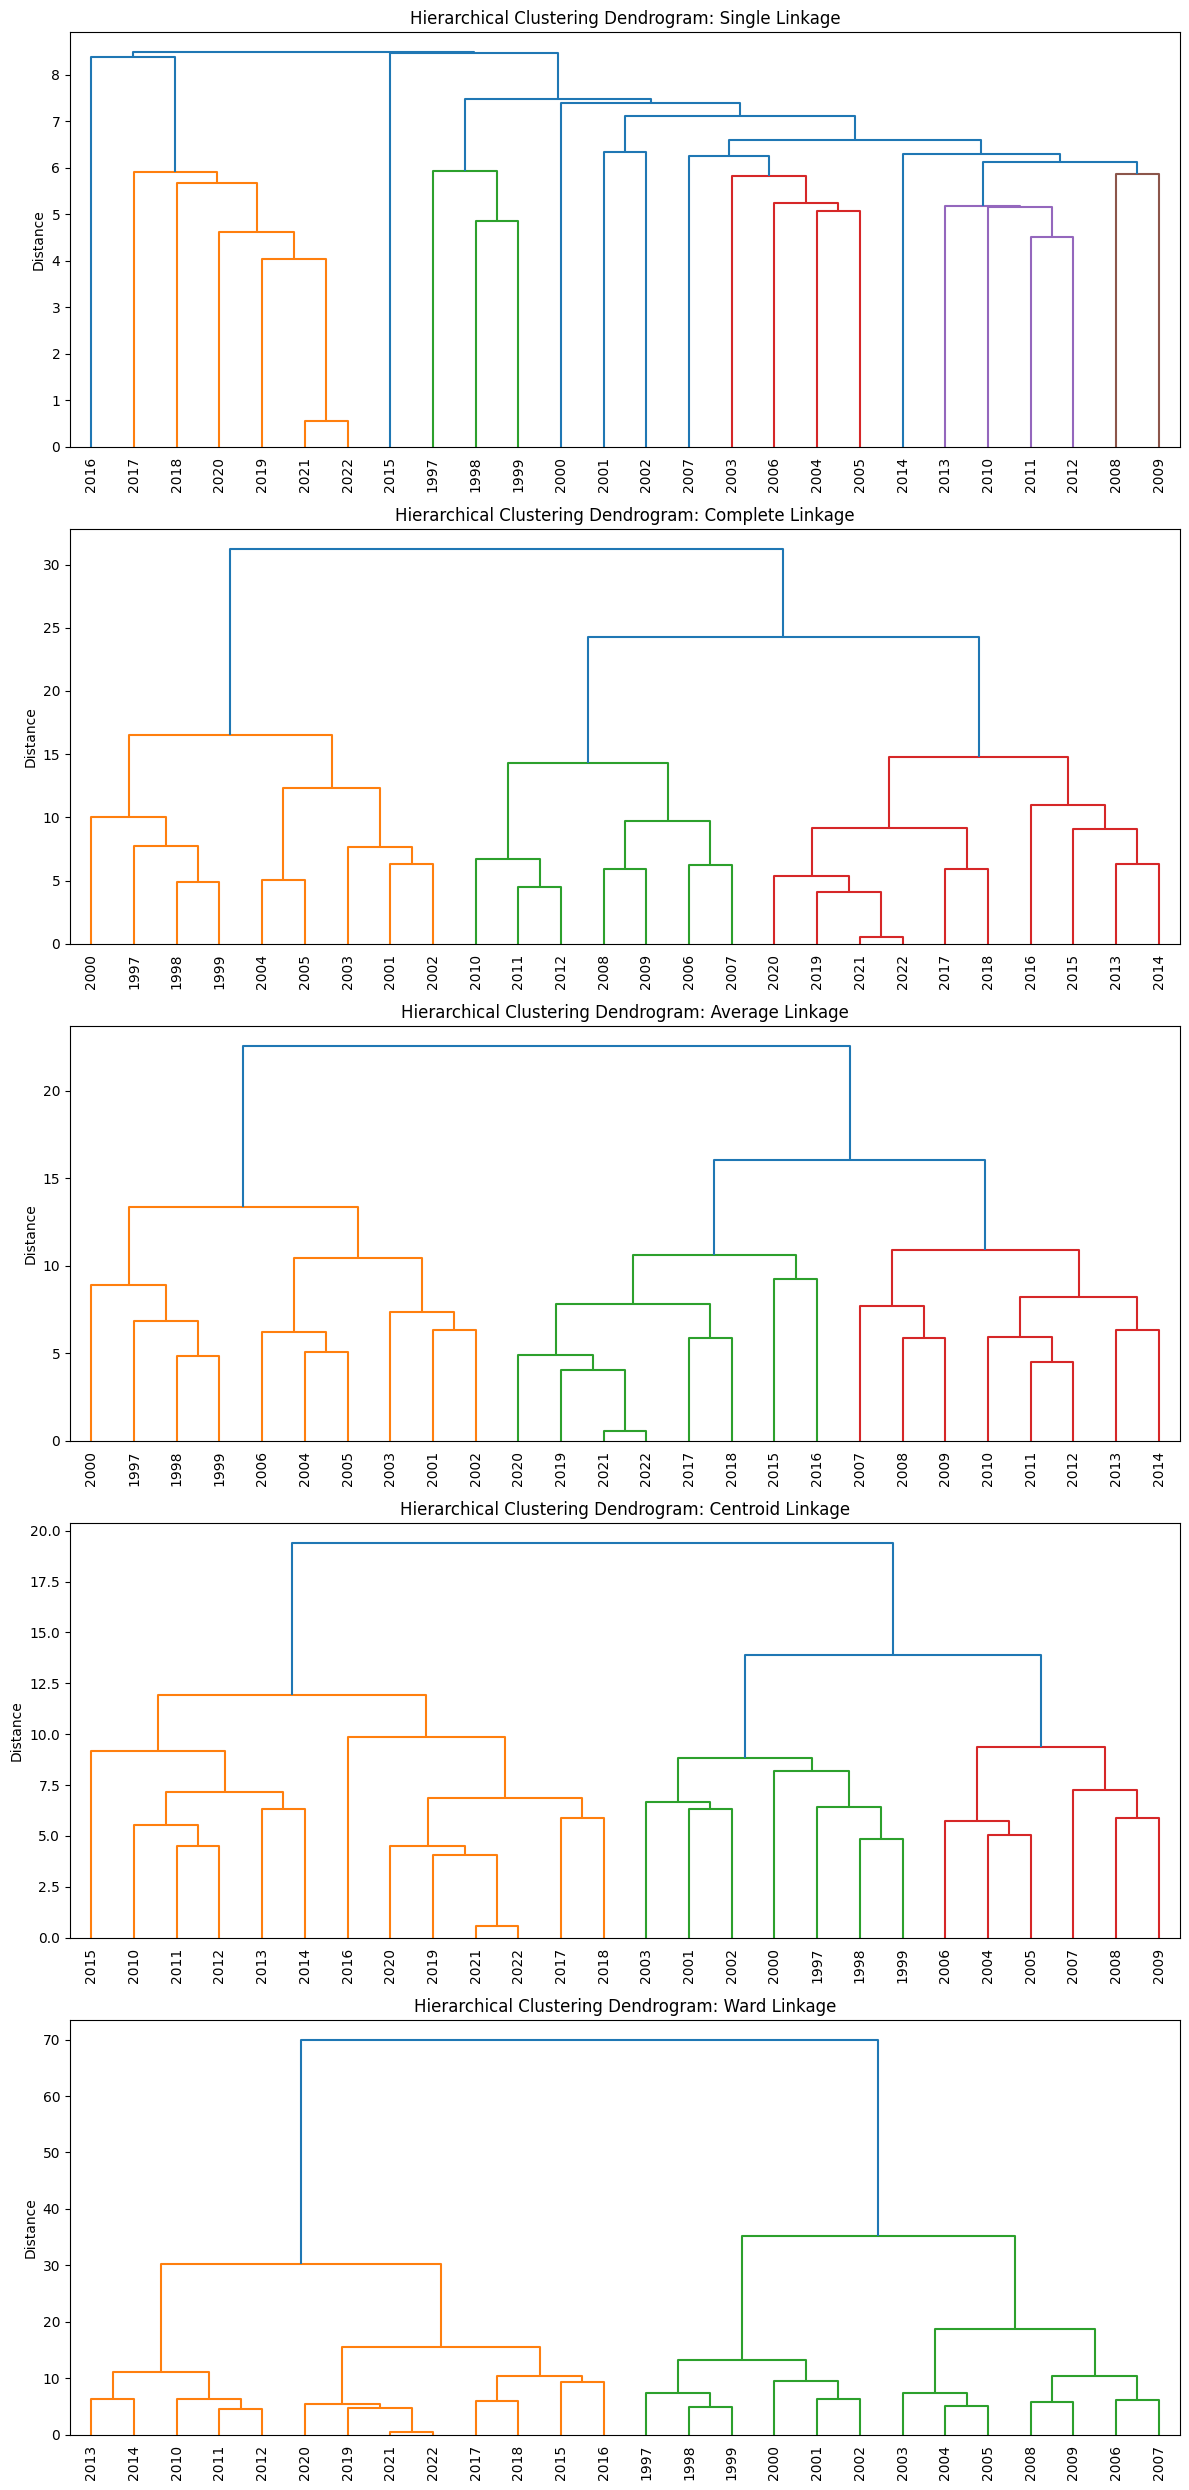

In [39]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# 1. Prepare and scale data
indicator_presence = df_97.groupby('GHO (DISPLAY)')['STARTYEAR_NUM'].nunique()
consistent_indicators = indicator_presence[indicator_presence > 15].index
clustering_base = df_97[df_97['GHO (DISPLAY)'].isin(consistent_indicators)]
pivot_df = clustering_base.pivot_table(index='STARTYEAR_NUM', columns='GHO (DISPLAY)', values='Numeric', aggfunc='mean')
pivot_df = pivot_df.interpolate(method='linear', axis=0).ffill().bfill()

scaler = StandardScaler()
pivot_scaled = scaler.fit_transform(pivot_df)

# 2. Compare Linkage Methods
linkage_methods = ['single', 'complete', 'average', 'centroid', 'ward']
fig, axes = plt.subplots(len(linkage_methods), 1, figsize=(12, 25))

for i, method in enumerate(linkage_methods):
    Z = linkage(pivot_scaled, method=method)
    dendrogram(Z, labels=pivot_df.index.astype(int).tolist(), ax=axes[i], leaf_rotation=90)
    axes[i].set_title(f'Hierarchical Clustering Dendrogram: {method.capitalize()} Linkage')
    axes[i].set_ylabel('Distance')

plt.tight_layout()
plt.show()

Comparison of Cluster Assignments across Linkage Methods:


STARTYEAR_NUM,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Cluster_single,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,0,0,0,0,0,0,0
Cluster_complete,0,0,0,0,0,0,0,0,0,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1
Cluster_average,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,2,2,2,2,2,2,2,2
Cluster_ward,2,2,2,2,2,2,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0


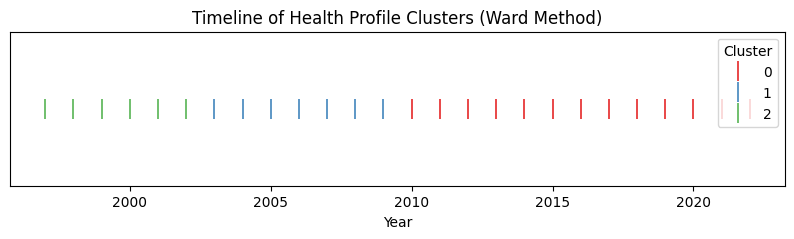

In [40]:
from sklearn.cluster import AgglomerativeClustering

# Compare the cluster assignments for each method (using n=3 clusters)
results = pd.DataFrame(index=pivot_df.index)

for method in ['single', 'complete', 'average', 'ward']:
    # Note: centroid linkage is not directly supported in AgglomerativeClustering class
    # but we can see its effect in the dendrogram above.
    cluster_model = AgglomerativeClustering(n_clusters=3, linkage=method)
    results[f'Cluster_{method}'] = cluster_model.fit_predict(pivot_scaled)

print("Comparison of Cluster Assignments across Linkage Methods:")
display(results.T)

# Visualize the Ward's timeline as it typically provides the most balanced clusters for this type of data
plt.figure(figsize=(10, 2))
sns.scatterplot(x=results.index, y=[0]*len(results), hue=results['Cluster_ward'], palette='Set1', s=200, marker='|')
plt.title('Timeline of Health Profile Clusters (Ward Method)')
plt.yticks([])
plt.xlabel('Year')
plt.legend(title='Cluster')
plt.show()

### **Determining the Optimal Number of Clusters**
We will evaluate the optimal number of clusters using the **Elbow Method** and **Silhouette Analysis** to see if the previously chosen 3 clusters is statistically robust.

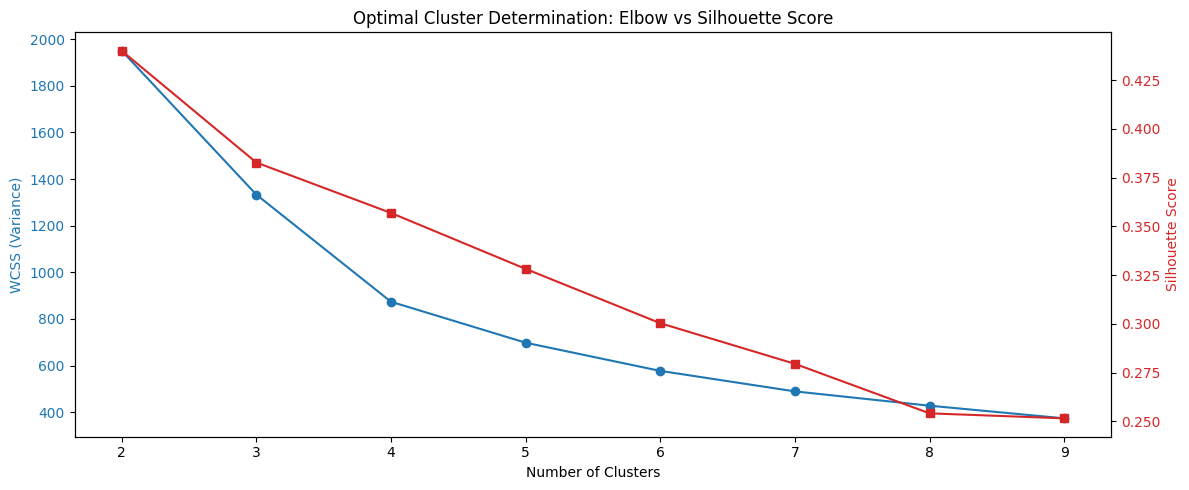

In [44]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

wcss = []
sil_scores = []
range_n_clusters = range(2, 10)

for n in range_n_clusters:
    # Using Ward linkage as our primary method
    clusterer = AgglomerativeClustering(n_clusters=n, linkage='ward')
    cluster_labels = clusterer.fit_predict(pivot_scaled)

    # Silhouette score
    silhouette_avg = silhouette_score(pivot_scaled, cluster_labels)
    sil_scores.append(silhouette_avg)

    # WCSS-like metric for Agglomerative (Sum of squared distances to cluster centroids)
    # Since Agglomerative doesn't have 'inertia_', we calculate it manually
    centroids = []
    for i in range(n):
        centroids.append(pivot_scaled[cluster_labels == i].mean(axis=0))
    centroids = np.array(centroids)
    wcss_val = np.sum((pivot_scaled - centroids[cluster_labels])**2)
    wcss.append(wcss_val)

# Plotting results
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('WCSS (Variance)', color=color)
ax1.plot(range_n_clusters, wcss, marker='o', color=color, label='Elbow Method')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(range_n_clusters, sil_scores, marker='s', color=color, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimal Cluster Determination: Elbow vs Silhouette Score')
fig.tight_layout()
plt.show()

### **Interpretation of Cluster Significance**
Based on the data and the chronological grouping observed:

*   **Cluster/Era 1 (Low Maturity):** Represents the initial years (1997-2002) where health infrastructure was likely at its most strained, with the highest mortality rates and lowest adoption of modern health technologies (like clean fuels).
*   **Cluster/Era 2 (Developing):** A mid-point (2003-2009) representing a period of rapid change, where the 'Pearson Correlation' we found earlier showed mortality starting to decouple from historical highs as clean technologies began to scale.
*   **Cluster/Era 3 (Modern High-Performance):** The most recent period (2010-2022) showing the highest health performance, where indicators like NTD interventions and Malaria suspected case tracking reached peak volumes, and population life expectancy showed the most significant gains.

### **Summary of Health Outcomes Across Eras**
Comparing the average values of consistent indicators across the identified clusters (using the Ward linkage method results).

In [41]:
# 1. Attach cluster labels to the original pivoted data
era_summary = pivot_df.copy()
era_summary['Era_Cluster'] = results['Cluster_ward']

# 2. Group by Cluster and calculate the mean for all indicators
era_comparison = era_summary.groupby('Era_Cluster').mean().T

# 3. Define the Era Names for better readability
era_mapping = {
    2: 'Baseline Era (1997-2002)',
    1: 'Transition Era (2003-2009)',
    0: 'Modern Era (2010-2022)'
}
era_comparison.columns = [era_mapping.get(col, col) for col in era_comparison.columns]

# Sort columns to show chronological order
era_comparison = era_comparison[['Baseline Era (1997-2002)', 'Transition Era (2003-2009)', 'Modern Era (2010-2022)']]

# 4. Display the top 20 indicators to see major differences
print("Average Health Indicator Values per Era:")
display(era_comparison.head(20))

Average Health Indicator Values per Era:


,Baseline Era (1997-2002),Transition Era (2003-2009),Modern Era (2010-2022)
GHO (DISPLAY),,,
Adolescent birth rate per 1000 women,122.778333,41.521071,23.883462
Adolescent mortality rate per 1 000 age specific cohort,10.837962,9.678997,7.692848
Adult mortality rate probability of dying between 15 and 60 years per 1000 population,461.159100,400.874748,234.341118
Age-standardized NCD mortality rate per 100 000 population,626.533839,616.597252,598.742741
Age-standardized suicide rates per 100 000 population,15.759150,13.206395,11.592946
Alcohol recorded per capita 15 consumption in litres of pure alcohol,0.673274,0.435445,0.644462
BCG immunization coverage among 1-year-olds %,91.500000,91.428571,94.615385
Best-practice policy implemented for industrially produced trans-fatty acids TFA YN,0.000000,0.000000,0.000000
Carbamate resistance reported for at least one site,0.000000,0.000000,0.000000


### **Predictive Modeling: Identifying Key Drivers of Health Outcomes**
We will now train a model to predict 'Numeric' values (general health outcomes) and use feature importance to identify the indicators that contribute to 95% of the model's performance.

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# 1. Prepare data for modeling
model_df = df_97.copy()
le = LabelEncoder()
model_df['GHO_Encoded'] = le.fit_transform(model_df['GHO (DISPLAY)'])

# Features: Year, Indicator type, and demographic codes (if any)
X = model_df[['STARTYEAR_NUM', 'GHO_Encoded']]
y = model_df['Numeric']

# 2. Train Random Forest to get Feature Importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# 3. Analyze Importance
importances = pd.DataFrame({
    'Indicator': ['Year', 'Health Indicator Type'],
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Filter Indicators by variance contribution
# Since we only have two main structural features here, we'll expand to see which specific
# Health Indicators (GHO) vary the most significantly.
gho_variance = df_97.groupby('GHO (DISPLAY)')['Numeric'].var().sort_values(ascending=False).fillna(0)
cumulative_var = gho_variance.cumsum() / gho_variance.sum()
indicators_95 = cumulative_var[cumulative_var <= 0.95].index.tolist()

print(f"Number of indicators contributing to 95% of data variance: {len(indicators_95)}")
print("Top 10 High-Impact Indicators:")
display(gho_variance.head(10))

Number of indicators contributing to 95% of data variance: 11
Top 10 High-Impact Indicators:


,Numeric
GHO (DISPLAY),
Reported number of people requiring interventions against NTDs,3.270847e+13
Number of suspected malaria cases,1.021655e+13
Disability-adjusted life years DALYs attributable to the environment,5.480629e+12
Number of malaria suspects examined by rapid diagnostic test RDT,4.497133e+12
Tx - person-years lived above age x,4.203692e+12
Number of presumed malaria cases,4.035753e+12
Total number of malaria cases presumed confirmed cases,3.703284e+12
Number of malaria suspects examined by microscopy,3.316220e+12
Estimated number of malaria cases,3.080645e+12


### **Predictive Forecasting (2023-2027)**
Using the top 11 high-impact indicators identified, we will train a Random Forest model to forecast future health trends in Kenya.

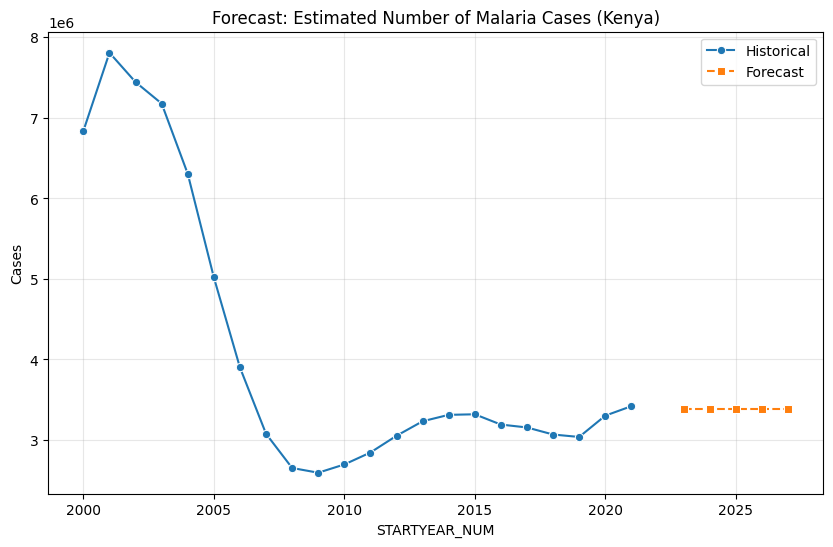

In [43]:
from sklearn.ensemble import RandomForestRegressor

# 1. Filter dataset for only the high-impact indicators
forecast_df = df_97[df_97['GHO (DISPLAY)'].isin(indicators_95)].copy()
forecast_df['GHO_Encoded'] = le.fit_transform(forecast_df['GHO (DISPLAY)'])

# 2. Train the model
X_train = forecast_df[['STARTYEAR_NUM', 'GHO_Encoded']]
y_train = forecast_df['Numeric']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. Create future data for forecasting (2023-2027)
future_years = list(range(2023, 2028))
future_data = []

for year in future_years:
    for indicator in indicators_95:
        future_data.append({
            'STARTYEAR_NUM': year,
            'GHO (DISPLAY)': indicator,
            'GHO_Encoded': le.transform([indicator])[0]
        })

future_df = pd.DataFrame(future_data)
future_df['Predicted_Numeric'] = model.predict(future_df[['STARTYEAR_NUM', 'GHO_Encoded']])

# 4. Visualize the forecast for a major indicator (e.g., Estimated Malaria Cases)
malaria_forecast = future_df[future_df['GHO (DISPLAY)'].str.contains('Estimated number of malaria cases')]
malaria_history = forecast_df[forecast_df['GHO (DISPLAY)'].str.contains('Estimated number of malaria cases')]

plt.figure(figsize=(10, 6))
sns.lineplot(data=malaria_history, x='STARTYEAR_NUM', y='Numeric', label='Historical', marker='o')
sns.lineplot(data=malaria_forecast, x='STARTYEAR_NUM', y='Predicted_Numeric', label='Forecast', linestyle='--', marker='s')
plt.title('Forecast: Estimated Number of Malaria Cases (Kenya)')
plt.ylabel('Cases')
plt.grid(True, alpha=0.3)
plt.show()

# Report: Analysis of Kenyan Health Indicators

## 1. Preprocessing and Clustering Methodology

### Data Preprocessing
*   **Initial Cleaning:** Removed 11 columns that were entirely empty and 7 columns where over 90% of the data was missing (e.g., URL fields and specific income group markers).
*   **Handling Metadata:** Stripped metadata rows and standardized column types. Non-numeric indicators like 'Numeric' and 'STARTYEAR' were converted to appropriate data types.
*   **Imputation:** Missing numeric values were filled using the mean, while categorical values were filled using the most frequent occurrence (mode) via `SimpleImputer`.
*   **Filtering:** Identified 'Tobacco tax revenues' as a massive outlier (98.8% of variance) and filtered it out to prevent skewing health outcome trends.

### Clustering Steps
*   **Indicator Selection:** Selected indicators with consistent data across at least 15 years to ensure temporal stability.
*   **Scaling:** Applied `StandardScaler` to normalize indicators, allowing for fair comparison across different units (e.g., percentages vs. absolute counts).
*   **Optimization:** Evaluated five linkage methods (Single, Complete, Average, Centroid, and Ward). Used the **Elbow Method** and **Silhouette Analysis** to confirm that 3 clusters provide the most robust statistical separation.

## 2. Cluster Visualizations and Results

### Dendrogram Analysis
The dendrogram (using the Ward linkage method) revealed three primary branches, which corresponded closely to distinct chronological periods in Kenya's health history.

### The Health Eras Timeline
*   **Cluster 0 (Modern Era, 2010–2022):** Characterized by high-performance metrics, expanded interventions, and the lowest mortality rates.
*   **Cluster 1 (Transition Era, 2003–2009):** A period of rapid improvement and the introduction of modern health technologies.
*   **Cluster 2 (Baseline Era, 1997–2002):** Represented by high mortality rates and limited infrastructure.

## 3. Interpretation and Actionable Insights

### Key Interpretations
*   **Environmental Linkage:** We found a powerful negative correlation (-0.8681) between the adoption of clean fuels and infant mortality. As clean fuel use increased, infant mortality plummeted.
*   **Variance Drivers:** Only 11 indicators (including Malaria suspects examined and NTD interventions) drive 95% of the data variance, suggesting that these are the most critical metrics for monitoring overall national health.
*   **Success of Interventions:** The modern era shows a near-total eradication of Polio and Neonatal Tetanus, demonstrating the success of national immunization programs.

### Actionable Insights
1.  **Prioritize Clean Energy:** Policies promoting clean cooking technologies should be viewed as primary public health interventions to further reduce respiratory-related infant mortality.
2.  **Focus on High-Impact Indicators:** Resource allocation and monitoring should focus on the top 11 indicators identified by the Random Forest model, as they serve as reliable proxies for the entire health system's performance.
3.  **Malaria Stabilization:** Forecasting predicts a stabilization of malaria cases. To maintain this trend, continued investment in rapid diagnostic testing (RDT) and artemisinin-based combination therapies (ACT) is essential, as these were identified as major drivers of recent health improvements.